# Image Captioning using Pretrained CLIP + GPT-2

This Colab notebook implements a student-friendly multimodal project:

**Pretrained CLIP image encoder + pretrained GPT-2 language model + trainable CLIP-to-GPT prefix mapper**

Only the small mapping network is trained. CLIP and GPT-2 stay frozen.

## Project pipeline

```text
Image
  ↓
Frozen CLIP image encoder
  ↓
CLIP image embedding
  ↓
Trainable prefix mapper
  ↓
GPT-2 prefix embeddings
  ↓
Frozen GPT-2
  ↓
Generated caption
```

## Dataset

This notebook uses the Hugging Face dataset:

```text
nlphuji/flickr30k
```

It contains images with human-written captions.


## 1. Colab setup

Before running:

1. Open **Runtime → Change runtime type**
2. Select **GPU**
3. Run all cells from top to bottom

The first run will download the dataset and pretrained models, so it may take longer.


In [1]:
!pip install -q transformers datasets accelerate pillow tqdm nltk matplotlib


## 2. Mount Google Drive and create folders

The trained mapper will be saved in your Google Drive.


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

PROJECT_DIR = "/content/drive/MyDrive/clip-caption-project"

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/outputs", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/samples", exist_ok=True)

print("Project folder:", PROJECT_DIR)


Project folder: /content/drive/MyDrive/clip-caption-project


## 3. Imports and configuration

For the first test, keep the dataset small. After the notebook works, increase `TRAIN_SIZE` and `EPOCHS`.


In [4]:
import os
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from transformers import CLIPProcessor, CLIPVisionModelWithProjection, GPT2Tokenizer, GPT2LMHeadModel
from tqdm.auto import tqdm
from PIL import Image
import matplotlib.pyplot as plt

# Reproducibility
random.seed(42)
torch.manual_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATASET_NAME = "lmms-lab/flickr30k"
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
GPT2_MODEL_NAME = "gpt2"

PREFIX_LENGTH = 10
MAX_CAPTION_LENGTH = 40
BATCH_SIZE = 8

# Start small for Colab. Increase later after everything works.
TRAIN_SIZE = 15000
VAL_SIZE = 1000
EPOCHS = 6
LEARNING_RATE = 2e-4
NUM_WORKERS = 2

print("Device:", DEVICE)


Device: cuda


## 4. Download and inspect Flickr30k

This uses Hugging Face `datasets`, so there is no manual Kaggle download needed.


In [5]:
# The older nlphuji/flickr30k loader uses a dataset script, which fails in datasets>=4.
# This modern mirror is stored as parquet and works in current Colab.

dataset = load_dataset(DATASET_NAME, split="test")

print(dataset)
print("Columns:", dataset.column_names)
print(dataset[0].keys())
print(dataset[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset({
    features: ['image', 'caption', 'sentids', 'img_id', 'filename'],
    num_rows: 31783
})
Columns: ['image', 'caption', 'sentids', 'img_id', 'filename']
dict_keys(['image', 'caption', 'sentids', 'img_id', 'filename'])
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=333x500 at 0x78044D405670>, 'caption': ['Two young guys with shaggy hair look at their hands while hanging out in the yard .', 'Two young  White males are outside near many bushes .', 'Two men in green shirts are standing in a yard .', 'A man in a blue shirt standing in a garden .', 'Two friends enjoy time spent together .'], 'sentids': ['0', '1', '2', '3', '4'], 'img_id': '0', 'filename': '1000092795.jpg'}


## 5. Prepare train/validation splits

Some versions of Flickr30k include a `split` column. If present, the notebook uses it. Otherwise, it creates a random train/test split.


In [6]:
if "split" in dataset.column_names:
    train_data = dataset.filter(lambda x: x["split"] == "train")
    val_data = dataset.filter(lambda x: x["split"] in ["val", "valid", "validation", "test"])
else:
    split_dataset = dataset.train_test_split(test_size=0.1, seed=42)
    train_data = split_dataset["train"]
    val_data = split_dataset["test"]

print("Full train size:", len(train_data))
print("Full validation/test size:", len(val_data))

train_data = train_data.shuffle(seed=42).select(range(min(TRAIN_SIZE, len(train_data))))
val_data = val_data.shuffle(seed=42).select(range(min(VAL_SIZE, len(val_data))))

print("Used train size:", len(train_data))
print("Used val size:", len(val_data))


Full train size: 28604
Full validation/test size: 3179
Used train size: 3000
Used val size: 300


## 6. Load pretrained CLIP and GPT-2

CLIP extracts image features. GPT-2 generates text.


In [7]:
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)

# IMPORTANT: use vision-only CLIP with projection
clip_model = CLIPVisionModelWithProjection.from_pretrained(CLIP_MODEL_NAME)

gpt2_tokenizer = GPT2Tokenizer.from_pretrained(GPT2_MODEL_NAME)
gpt2_model = GPT2LMHeadModel.from_pretrained(GPT2_MODEL_NAME)

gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token
gpt2_model.config.pad_token_id = gpt2_tokenizer.eos_token_id

print("CLIP projection dim:", clip_model.config.projection_dim)
print("GPT-2 embedding dim:", gpt2_model.config.n_embd)

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

CLIPVisionModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.embeddings.token_embedding.weight                 | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.final_layer_norm.bias           

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP projection dim: 512
GPT-2 embedding dim: 768


## 7. PyTorch dataset class

Each image usually has multiple captions. During training, one caption is randomly selected.


In [8]:
class FlickrCaptionDataset(Dataset):
    def __init__(self, hf_dataset, clip_processor, tokenizer, max_caption_length=40):
        self.dataset = hf_dataset
        self.clip_processor = clip_processor
        self.tokenizer = tokenizer
        self.max_caption_length = max_caption_length

    def __len__(self):
        return len(self.dataset)

    def _get_caption(self, item):
        # Common case for nlphuji/flickr30k
        if "caption" in item:
            captions = item["caption"]
        elif "captions" in item:
            captions = item["captions"]
        elif "sentence" in item:
            captions = item["sentence"]
        else:
            raise KeyError("Could not find a caption column. Check dataset columns.")

        if isinstance(captions, list):
            return random.choice(captions)

        return str(captions)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        if "image" not in item:
            raise KeyError("Could not find an image column. Check dataset columns.")

        image = item["image"]

        if not isinstance(image, Image.Image):
            image = Image.open(image)

        image = image.convert("RGB")
        caption = self._get_caption(item)

        pixel_values = self.clip_processor(
            images=image,
            return_tensors="pt"
        )["pixel_values"].squeeze(0)

        tokenized = self.tokenizer(
            caption,
            padding="max_length",
            truncation=True,
            max_length=self.max_caption_length,
            return_tensors="pt"
        )

        input_ids = tokenized["input_ids"].squeeze(0)
        attention_mask = tokenized["attention_mask"].squeeze(0)

        return {
            "pixel_values": pixel_values,
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "caption": caption
        }


In [9]:
train_dataset = FlickrCaptionDataset(
    train_data,
    clip_processor,
    gpt2_tokenizer,
    max_caption_length=MAX_CAPTION_LENGTH
)

val_dataset = FlickrCaptionDataset(
    val_data,
    clip_processor,
    gpt2_tokenizer,
    max_caption_length=MAX_CAPTION_LENGTH
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

batch = next(iter(train_loader))
print("Image batch shape:", batch["pixel_values"].shape)
print("Caption token batch shape:", batch["input_ids"].shape)
print("Example caption:", batch["caption"][0])


Image batch shape: torch.Size([8, 3, 224, 224])
Caption token batch shape: torch.Size([8, 40])
Example caption: A young boy in a pool


## 8. Define the CLIP-to-GPT-2 captioning model

This is the main project contribution.

The model learns a small neural network:

```text
CLIP image embedding → GPT-2 soft prefix embeddings
```

The prefix embeddings are placed before the caption tokens, so GPT-2 can generate text conditioned on the image.


In [10]:
class ClipGPT2CaptionModel(nn.Module):
    def __init__(
        self,
        clip_model,
        gpt2_model,
        prefix_length=10,
        freeze_clip=True,
        freeze_gpt2=True
    ):
        super().__init__()

        self.clip = clip_model
        self.gpt2 = gpt2_model
        self.prefix_length = prefix_length

        self.clip_dim = self.clip.config.projection_dim
        self.gpt2_dim = self.gpt2.config.n_embd

        self.prefix_mapper = nn.Sequential(
            nn.Linear(self.clip_dim, 512),
            nn.Tanh(),
            nn.Linear(512, self.prefix_length * self.gpt2_dim)
        )

        if freeze_clip:
            for param in self.clip.parameters():
                param.requires_grad = False

        if freeze_gpt2:
            for param in self.gpt2.parameters():
                param.requires_grad = False

    def get_clip_image_features(self, pixel_values):
        """
        Returns image embeddings as a tensor of shape:
        [batch_size, clip_projection_dim]
        """
        outputs = self.clip(
            pixel_values=pixel_values,
            return_dict=True
        )

        image_features = outputs.image_embeds

        return image_features

    def forward(self, pixel_values, input_ids, attention_mask):
        batch_size = pixel_values.size(0)

        with torch.no_grad():
            image_features = self.get_clip_image_features(pixel_values)

        # Safety check
        if not torch.is_tensor(image_features):
            raise TypeError(f"image_features must be Tensor, got {type(image_features)}")

        prefix_embeddings = self.prefix_mapper(image_features)

        prefix_embeddings = prefix_embeddings.view(
            batch_size,
            self.prefix_length,
            self.gpt2_dim
        )

        token_embeddings = self.gpt2.transformer.wte(input_ids)

        inputs_embeds = torch.cat(
            [prefix_embeddings, token_embeddings],
            dim=1
        )

        prefix_attention_mask = torch.ones(
            batch_size,
            self.prefix_length,
            device=attention_mask.device
        )

        full_attention_mask = torch.cat(
            [prefix_attention_mask, attention_mask],
            dim=1
        )

        prefix_labels = torch.full(
            (batch_size, self.prefix_length),
            -100,
            device=input_ids.device
        )

        labels = input_ids.clone()
        labels[labels == gpt2_tokenizer.pad_token_id] = -100

        full_labels = torch.cat(
            [prefix_labels, labels],
            dim=1
        )

        outputs = self.gpt2(
            inputs_embeds=inputs_embeds,
            attention_mask=full_attention_mask,
            labels=full_labels
        )

        return outputs

In [11]:
model = ClipGPT2CaptionModel(
    clip_model=clip_model,
    gpt2_model=gpt2_model,
    prefix_length=PREFIX_LENGTH,
    freeze_clip=True,
    freeze_gpt2=True
).to(DEVICE)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print("Trainable parameters:", trainable_params)
print("Total parameters:", total_params)
print("Trainable %:", round(100 * trainable_params / total_params, 4))


Trainable parameters: 4202496
Total parameters: 216491520
Trainable %: 1.9412


In [12]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE
)

## 9. Training and validation loops


In [13]:

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0

    progress_bar = tqdm(dataloader, desc="Training")

    for batch in progress_bar:
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        optimizer.zero_grad()

        outputs = model(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({"loss": loss.item()})

    return total_loss / len(dataloader)


@torch.no_grad()
def evaluate_loss(model, dataloader, device):
    model.eval()
    total_loss = 0.0

    for batch in tqdm(dataloader, desc="Validation"):
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        total_loss += outputs.loss.item()

    return total_loss / len(dataloader)


## 10. Train the mapper

This trains only the prefix mapper. CLIP and GPT-2 remain frozen.


In [14]:
history = {
    "train_loss": [],
    "val_loss": []
}

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        DEVICE
    )

    val_loss = evaluate_loss(
        model,
        val_loader,
        DEVICE
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print("Train loss:", train_loss)
    print("Val loss:", val_loss)



Epoch 1/3


Training:   0%|          | 0/375 [00:00<?, ?it/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Validation:   0%|          | 0/38 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78058818d300>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x78058818d300>if w.is_alive():
Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Exception ignored in:      <function _MultiProcessingDataLoaderIter.__del__ at 0x78058818d300> self._shutdown_workers()
 
Traceback (most recent call last):
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78058818d300>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

   File "/usr/local/l

...

Train loss: 3.3367282581329345
Val loss: 3.080319548908033

Epoch 3/3


Training:   0%|          | 0/375 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78058818d300>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x78058818d300>
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
Traceback (most recent call last):
if w.is_alive():      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    
self._shutdown_workers()  
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():  
     ^ ^ ^ ^ ^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

      File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
assert self._par

Validation:   0%|          | 0/38 [00:00<?, ?it/s]

Train loss: 3.2430013275146483
Val loss: 3.0651921347567908


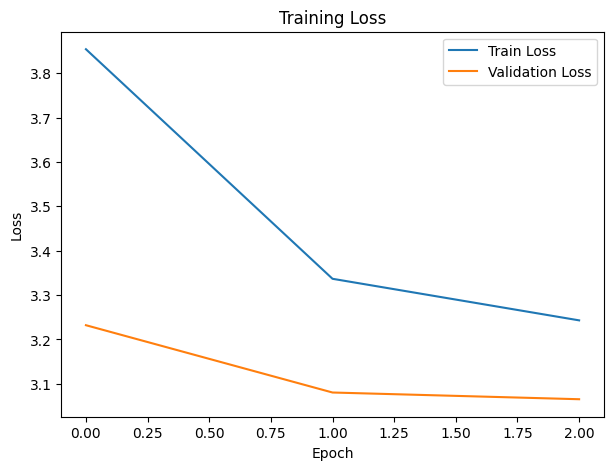

In [15]:
plt.figure(figsize=(7, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.show()


## 11. Save the trained mapper


In [16]:
SAVE_PATH = f"{PROJECT_DIR}/outputs/clip_gpt2_prefix.pt"

torch.save({
    "prefix_mapper_state_dict": model.prefix_mapper.state_dict(),
    "prefix_length": PREFIX_LENGTH,
    "clip_model_name": CLIP_MODEL_NAME,
    "gpt2_model_name": GPT2_MODEL_NAME,
    "history": history
}, SAVE_PATH)

print("Saved to:", SAVE_PATH)


Saved to: /content/drive/MyDrive/clip-caption-project/outputs/clip_gpt2_prefix.pt


## 12. Caption generation function


In [19]:
@torch.no_grad()
def generate_caption(model, image, clip_processor, tokenizer, device, max_new_tokens=25):
    model.eval()

    if not isinstance(image, Image.Image):
        image = Image.open(image)

    image = image.convert("RGB")

    pixel_values = clip_processor(
        images=image,
        return_tensors="pt"
    )["pixel_values"].to(device)

    image_features = model.get_clip_image_features(pixel_values)

    prefix_embeddings = model.prefix_mapper(image_features)

    prefix_embeddings = prefix_embeddings.view(
        1,
        model.prefix_length,
        model.gpt2_dim
    )

    attention_mask = torch.ones(
        1,
        model.prefix_length,
        device=device
    )

    generated_ids = model.gpt2.generate(
        inputs_embeds=prefix_embeddings,
        attention_mask=attention_mask,
        max_new_tokens=max_new_tokens,
        num_beams=5,
        do_sample=False,
        no_repeat_ngram_size=3,
        repetition_penalty=1.25,
        length_penalty=0.9,
        early_stopping=True,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id
    )

    caption = tokenizer.decode(
        generated_ids[0],
        skip_special_tokens=True
    )

    caption = caption.strip()

    # Clean repeated weird output after first strong sentence
    if "\n" in caption:
        caption = caption.split("\n")[0].strip()

    return caption

## 13. Test generated captions on validation images


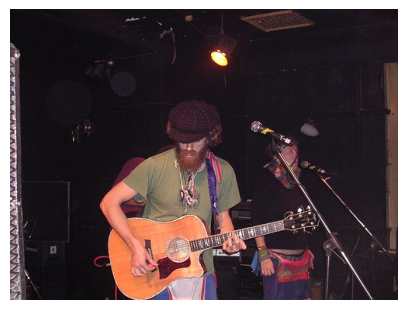

Generated caption:
A man is playing a guitar in front of a crowd . He is wearing a white shirt and a black shirt . The man plays the guitar while wearing

Real captions:
- A man in a brown hat and green t-shirt is playing the guitar with a band behind him .
- A man in a green shirt and black hat playing a guitar on stage .
- A man in a green shirt playing an acoustic guitar .
- A man playing the guitar on stage at a concert
- A gentleman playing guitar in a band .


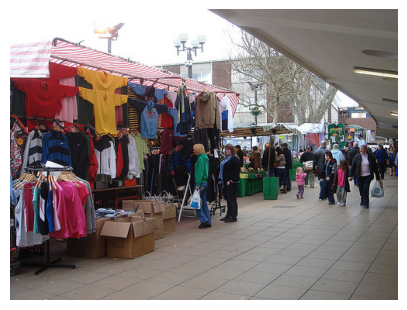

Generated caption:
A group of people are shopping at a local grocery store . The store is located in the middle of the street . A man walks up to the man

Real captions:
- Two women  one in a green jacket and another in a black jacket  are looking at shirts at an outside flea market .
- 2 friends are looking at clothes at a stand while at a shopping mall .
- There is a flea market with many shoppers during late fall or winter .
- People are shopping and browsing at outdoor vendors .
- people shop around an outdoor system of stores .


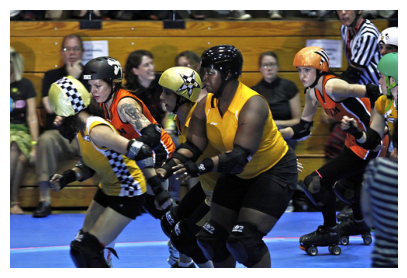

Generated caption:
A woman is wearing a red shirt and blue shorts and a blue shirt . The women are wearing red and white polo shirts . One of the women

Real captions:
- Three girls in yellow jerseys and two girls in orange jerseys are competing in a Roller Derby event .
- Two teams of women in orange and yellow compete on rollerskates while a crowd watches .
- A group of spectators are watching woman playing in a roller derby .
- A group of women are participating in a roller derby game .
- A group of women rollerskating .


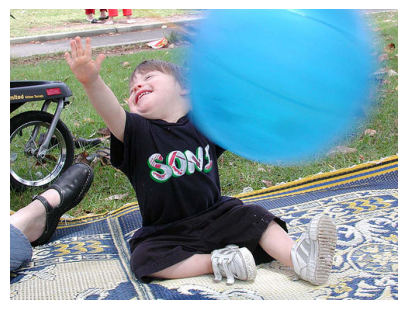

Generated caption:
A young boy is playing with a balloon . The boy holds the balloon up to the boy's face .

A child plays in the backyard of

Real captions:
- Happy  smiley toddler sitting in a pretty blue  white and yellow blanket throwing a large blue ball .
- A little boy is playing with a ball while sitting on a rug that is on the grass .
- In this picture  a child is playing with a large blue ball .
- A small child smiles as a ball flies towards his face .
- A boy laughs as he is hit with a beach ball .


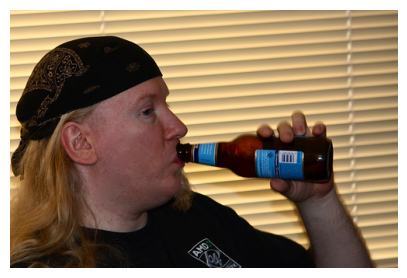

Generated caption:
A man with a beard is smoking a beer . The man is wearing a red shirt and a blue shirt . He is talking to a man in a

Real captions:
- A person with long  blond-hair wearing a bandanna drinks from a beer bottle while standing in front of window blinds .
- A white male with blond-hair is drinking beer .
- A man with long hair is drinking a beer .
- A man drinking out of a glass bottle .
- A man is drinking a beer .


In [20]:
for i in range(5):
    item = val_data[i]
    image = item["image"].convert("RGB")
    real_captions = item["caption"] if "caption" in item else item.get("captions", "")

    predicted_caption = generate_caption(
        model,
        image,
        clip_processor,
        gpt2_tokenizer,
        DEVICE
    )

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    print("Generated caption:")
    print(predicted_caption)

    print("\nReal captions:")
    if isinstance(real_captions, list):
        for cap in real_captions:
            print("-", cap)
    else:
        print("-", real_captions)

    print("=" * 80)


## 14. Test on your own image

Upload your image to:

```text
/content/drive/MyDrive/clip-caption-project/samples/test.jpg
```

Then run the next cell.


In [ ]:
test_image_path = f"{PROJECT_DIR}/samples/test.jpg"

if os.path.exists(test_image_path):
    image = Image.open(test_image_path).convert("RGB")

    caption = generate_caption(
        model,
        image,
        clip_processor,
        gpt2_tokenizer,
        DEVICE
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    print("Generated caption:", caption)
else:
    print("No test image found.")
    print("Upload an image to:", test_image_path)


## 15. BLEU evaluation

BLEU is a simple automatic captioning metric. For your report, include BLEU-1 and BLEU-4.


In [ ]:
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

nltk.download("punkt")

def simple_tokenize(text):
    return text.lower().strip().split()

@torch.no_grad()
def evaluate_bleu(model, val_data, num_samples=100):
    references = []
    hypotheses = []

    smoothie = SmoothingFunction().method4

    for i in tqdm(range(min(num_samples, len(val_data))), desc="BLEU Evaluation"):
        item = val_data[i]
        image = item["image"].convert("RGB")

        if "caption" in item:
            refs = item["caption"]
        elif "captions" in item:
            refs = item["captions"]
        else:
            refs = [item["sentence"]]

        if not isinstance(refs, list):
            refs = [str(refs)]

        pred = generate_caption(
            model,
            image,
            clip_processor,
            gpt2_tokenizer,
            DEVICE
        )

        references.append([simple_tokenize(r) for r in refs])
        hypotheses.append(simple_tokenize(pred))

    bleu1 = corpus_bleu(
        references,
        hypotheses,
        weights=(1, 0, 0, 0),
        smoothing_function=smoothie
    )

    bleu4 = corpus_bleu(
        references,
        hypotheses,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoothie
    )

    return bleu1, bleu4


bleu1, bleu4 = evaluate_bleu(model, val_data, num_samples=100)

print("BLEU-1:", bleu1)
print("BLEU-4:", bleu4)


## 16. Save sample generated captions to a text file


In [ ]:
RESULTS_PATH = f"{PROJECT_DIR}/outputs/sample_captions.txt"

with open(RESULTS_PATH, "w", encoding="utf-8") as f:
    for i in range(20):
        item = val_data[i]
        image = item["image"].convert("RGB")

        refs = item["caption"] if "caption" in item else item.get("captions", "")

        pred = generate_caption(
            model,
            image,
            clip_processor,
            gpt2_tokenizer,
            DEVICE
        )

        f.write(f"Sample {i+1}\n")
        f.write(f"Generated: {pred}\n")
        f.write("References:\n")

        if isinstance(refs, list):
            for r in refs:
                f.write(f"- {r}\n")
        else:
            f.write(f"- {refs}\n")

        f.write("\n" + "=" * 80 + "\n\n")

print("Saved sample captions to:", RESULTS_PATH)


## 17. Optional: load a saved mapper later

Use this cell when you come back later and want to load the trained mapper without retraining.


In [ ]:
# Optional reload cell.
# Run this only after loading CLIP, GPT-2, defining ClipGPT2CaptionModel, and creating `model`.

LOAD_PATH = f"{PROJECT_DIR}/outputs/clip_gpt2_prefix.pt"

if os.path.exists(LOAD_PATH):
    checkpoint = torch.load(LOAD_PATH, map_location=DEVICE)
    model.prefix_mapper.load_state_dict(checkpoint["prefix_mapper_state_dict"])
    model.to(DEVICE)
    model.eval()
    print("Loaded mapper from:", LOAD_PATH)
else:
    print("No saved mapper found at:", LOAD_PATH)


# Report notes

Use these points in your final report:

## Methodology

- CLIP image encoder extracts visual embeddings from each image.
- A trainable prefix mapper converts CLIP image embeddings into GPT-2-compatible prefix embeddings.
- GPT-2 receives the learned image prefix and generates captions.
- CLIP and GPT-2 are frozen.
- Only the mapper is trained.

## Evaluation

- Training loss
- Validation loss
- BLEU-1
- BLEU-4
- Human comparison of generated and reference captions

## Limitations

- Captions may be generic.
- The model uses a global CLIP embedding, so it may miss small objects.
- GPT-2 was not originally trained as an image-captioning model.
- Small training subsets reduce caption quality.

## Future work

- Train on more Flickr30k samples.
- Try MS-COCO.
- Fine-tune part of GPT-2.
- Compare with BLIP.
- Add CIDEr evaluation.
